In [7]:
import pandas as pd

# path to your file
file_path = "../archive/data/spotify-streaming-top-50-usa.csv"

# read CSV
df = pd.read_csv(file_path)

# preview
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,release_date,is_explicit,album_cover_url
0,2023-05-18,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,2023-04-28,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,2023-05-18,2,Last Night,Morgan Wallen,89,163854,album,36,2023-03-03,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,2023-05-18,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,2023-05-12,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,2023-05-18,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,2023-04-17,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,2023-05-18,5,Kill Bill,SZA,94,153946,album,23,2022-12-08,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [8]:
df = df.rename(columns={
    "position": "rank"
})
df["date"] = pd.to_datetime(df["date"])
df["song_id"] = df["song"] + " - " + df["artist"]
df = df.sort_values(["song_id", "date"])
df = df[["date", "rank", "song", "artist", "song_id"]]
df.head()

,date,rank,song,artist,song_id
8202,2023-10-29,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ..."
8252,2023-10-30,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ..."
8302,2023-10-31,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ..."
8354,2023-11-01,5,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ..."
8402,2023-11-02,3,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ..."


In [9]:
'''
State definitions

S0 - rank 1-10
S2 - rank 11-20
S3 - rank 21-30
S4 - rank 31-40
S5 - rank 41-50
S16 - off of the chart (has been on the chart before) 

'''

def get_state(rank):
    if 1 <= rank <= 10:
        return "1-10"
    elif 11 <= rank <= 20:
        return "11-20"
    elif 21 <= rank <= 30:
        return "21-30"
    elif 31 <= rank <= 40:
        return "31-40"
    elif 41 <= rank <= 50:
        return "41-50"
    else:
        return None

df["state"] = df["rank"].apply(get_state)
df = df[["date", "rank", "song", "artist", "song_id", "state"]].copy()



for each song, create a row for every day from its first chart appearance to the end of the dataset
If the song appears that day, keep its actual state
If it does not appear that day, label it off-chart

In [10]:
sample_end = df["date"].max()

full_panels = []

for song_id, group in df.groupby("song_id"):
    group = group.sort_values("date").copy()
    
    first_date = group["date"].min()
    full_dates = pd.DataFrame({
        "date": pd.date_range(start=first_date, end=sample_end, freq="D")
    })
    
    merged = full_dates.merge(
        group[["date", "rank", "song", "artist", "song_id", "state"]],
        on="date",
        how="left"
    )
    
    merged["song_id"] = song_id
    merged["song"] = merged["song"].ffill().bfill()
    merged["artist"] = merged["artist"].ffill().bfill()
    merged["state"] = merged["state"].fillna("off-chart")
    
    full_panels.append(merged)

panel_df = pd.concat(full_panels, ignore_index=True)
panel_df = panel_df.sort_values(["song_id", "date"]).reset_index(drop=True)
panel_df["next_state"] = panel_df.groupby("song_id")["state"].shift(-1)

panel_df.head(15)

,date,rank,song,artist,song_id,state,next_state
0,2023-10-29,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
1,2023-10-30,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
2,2023-10-31,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
3,2023-11-01,5.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
4,2023-11-02,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
5,2023-11-03,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
6,2023-11-04,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
7,2023-11-05,3.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
8,2023-11-06,4.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10
9,2023-11-07,7.0,"""Slut!"" (Taylor's Version) (From The Vault)",Taylor Swift,"""Slut!"" (Taylor's Version) (From The Vault) - ...",1-10,1-10


Generate the transition probability matrix

In [11]:
transitions_df = panel_df.dropna(subset=["next_state"]).copy()
transitions_df[["date", "song", "state", "next_state"]].head(20)

,date,song,state,next_state
0,2023-10-29,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
1,2023-10-30,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
2,2023-10-31,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
3,2023-11-01,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
4,2023-11-02,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
5,2023-11-03,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
6,2023-11-04,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
7,2023-11-05,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
8,2023-11-06,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10
9,2023-11-07,"""Slut!"" (Taylor's Version) (From The Vault)",1-10,1-10


In [12]:
transition_counts = pd.crosstab(
    transitions_df["state"],
    transitions_df["next_state"]
)

transition_counts

next_state,1-10,11-20,21-30,31-40,41-50,off-chart
state,,,,,,
1-10,4923,443,85,24,7,68
11-20,317,4298,647,133,49,106
21-30,12,513,3849,823,165,188
31-40,3,40,713,3530,846,418
41-50,2,7,58,768,3351,1364
off-chart,62,58,71,135,891,285158


In [13]:
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
state_order = ["1-10", "11-20", "21-30", "31-40", "41-50", "off-chart"]

transition_counts = transition_counts.reindex(index=state_order, columns=state_order, fill_value=0)
transition_matrix = transition_matrix.reindex(index=state_order, columns=state_order)

transition_counts
transition_matrix

next_state,1-10,11-20,21-30,31-40,41-50,off-chart
state,,,,,,
1-10,0.887027,0.079820,0.015315,0.004324,0.001261,0.012252
11-20,0.057117,0.774414,0.116577,0.023964,0.008829,0.019099
21-30,0.002162,0.092432,0.693514,0.148288,0.029730,0.033874
31-40,0.000541,0.007207,0.128468,0.636036,0.152432,0.075315
41-50,0.000360,0.001261,0.010450,0.138378,0.603784,0.245766
off-chart,0.000216,0.000203,0.000248,0.000471,0.003111,0.995750


# Data Vizualization

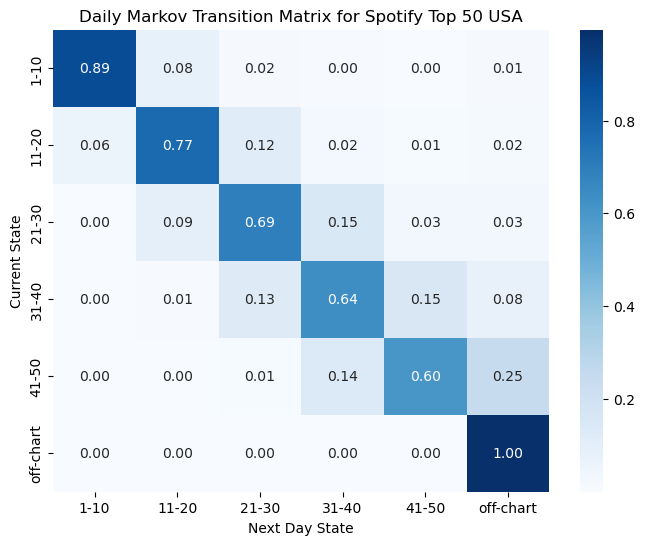

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Daily Markov Transition Matrix for Spotify Top 50 USA")
plt.xlabel("Next Day State")
plt.ylabel("Current State")
plt.show()

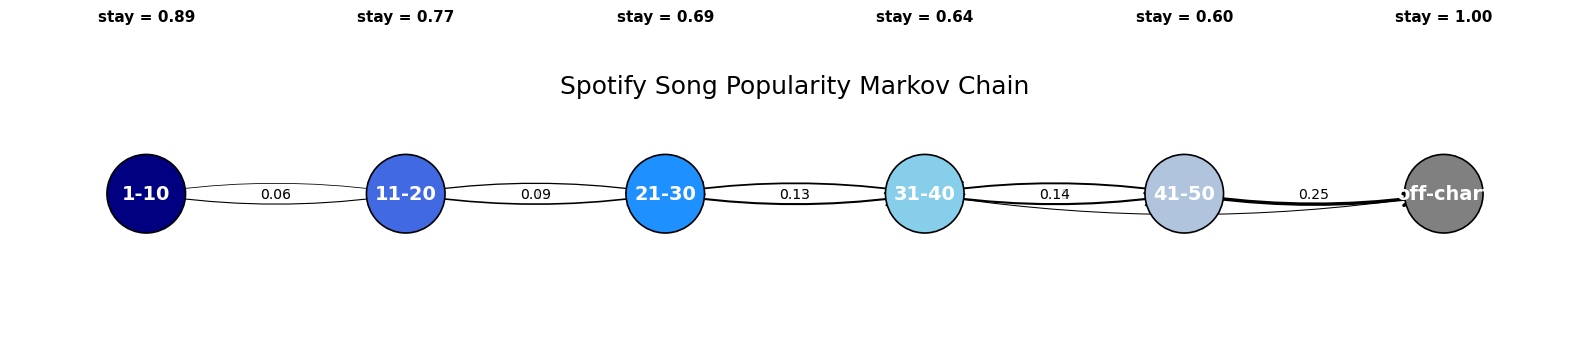

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

# ordered states
states = ["1-10", "11-20", "21-30", "31-40", "41-50", "off-chart"]

# build graph with ONLY non-self transitions above threshold
G = nx.DiGraph()
for state in states:
    G.add_node(state)

threshold = 0.05  # only show non-self transitions >= 5%

for from_state in states:
    for to_state in states:
        prob = transition_matrix.loc[from_state, to_state]
        if from_state != to_state and prob >= threshold:
            G.add_edge(from_state, to_state, weight=prob)

# cleaner pyramid layout
pos = {
    "1-10":      (0, 0),
    "11-20":     (1, 0),
    "21-30":     (2, 0),
    "31-40":     (3, 0),
    "41-50":     (4, 0),
    "off-chart": (5, 0)
}
# node colors
node_color_map = {
    "1-10": "navy",
    "11-20": "royalblue",
    "21-30": "dodgerblue",
    "31-40": "skyblue",
    "41-50": "lightsteelblue",
    "off-chart": "gray"
}
node_colors = [node_color_map[state] for state in states]

# edge widths scaled by probability
edge_widths = [10 * G[u][v]["weight"] for u, v in G.edges()]

# edge labels
edge_labels = {
    (u, v): f"{G[u][v]['weight']:.2f}"
    for u, v in G.edges()
}

plt.figure(figsize=(16, 4))

# draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3200,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1.2
)

# draw node labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=14,
    font_color="white",
    font_weight="bold"
)

# draw edges
nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=22,
    width=edge_widths,
    edge_color="black",
    min_source_margin=18,
    min_target_margin=18,
    connectionstyle="arc3,rad=0.08"
)

# draw edge labels
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10,
    rotate=False,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.2)
)

# add self-transition probabilities as text above nodes
for state in states:
    x, y = pos[state]
    stay_prob = transition_matrix.loc[state, state]
    plt.text(
        x, y + 0.45,
        f"stay = {stay_prob:.2f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.2)
    )

plt.title("Spotify Song Popularity Markov Chain", fontsize=18, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()


DISCRETE-TIME MARKOV CHAIN
 SIZE:           6
 RANK:           6
 CLASSES:        1
  > RECURRENT:   1
  > TRANSIENT:   0
 ERGODIC:        YES
  > APERIODIC:   YES
  > IRREDUCIBLE: YES
 ABSORBING:      NO
 MONOTONE:       YES
 REGULAR:        YES
 REVERSIBLE:     NO
 SYMMETRIC:      NO



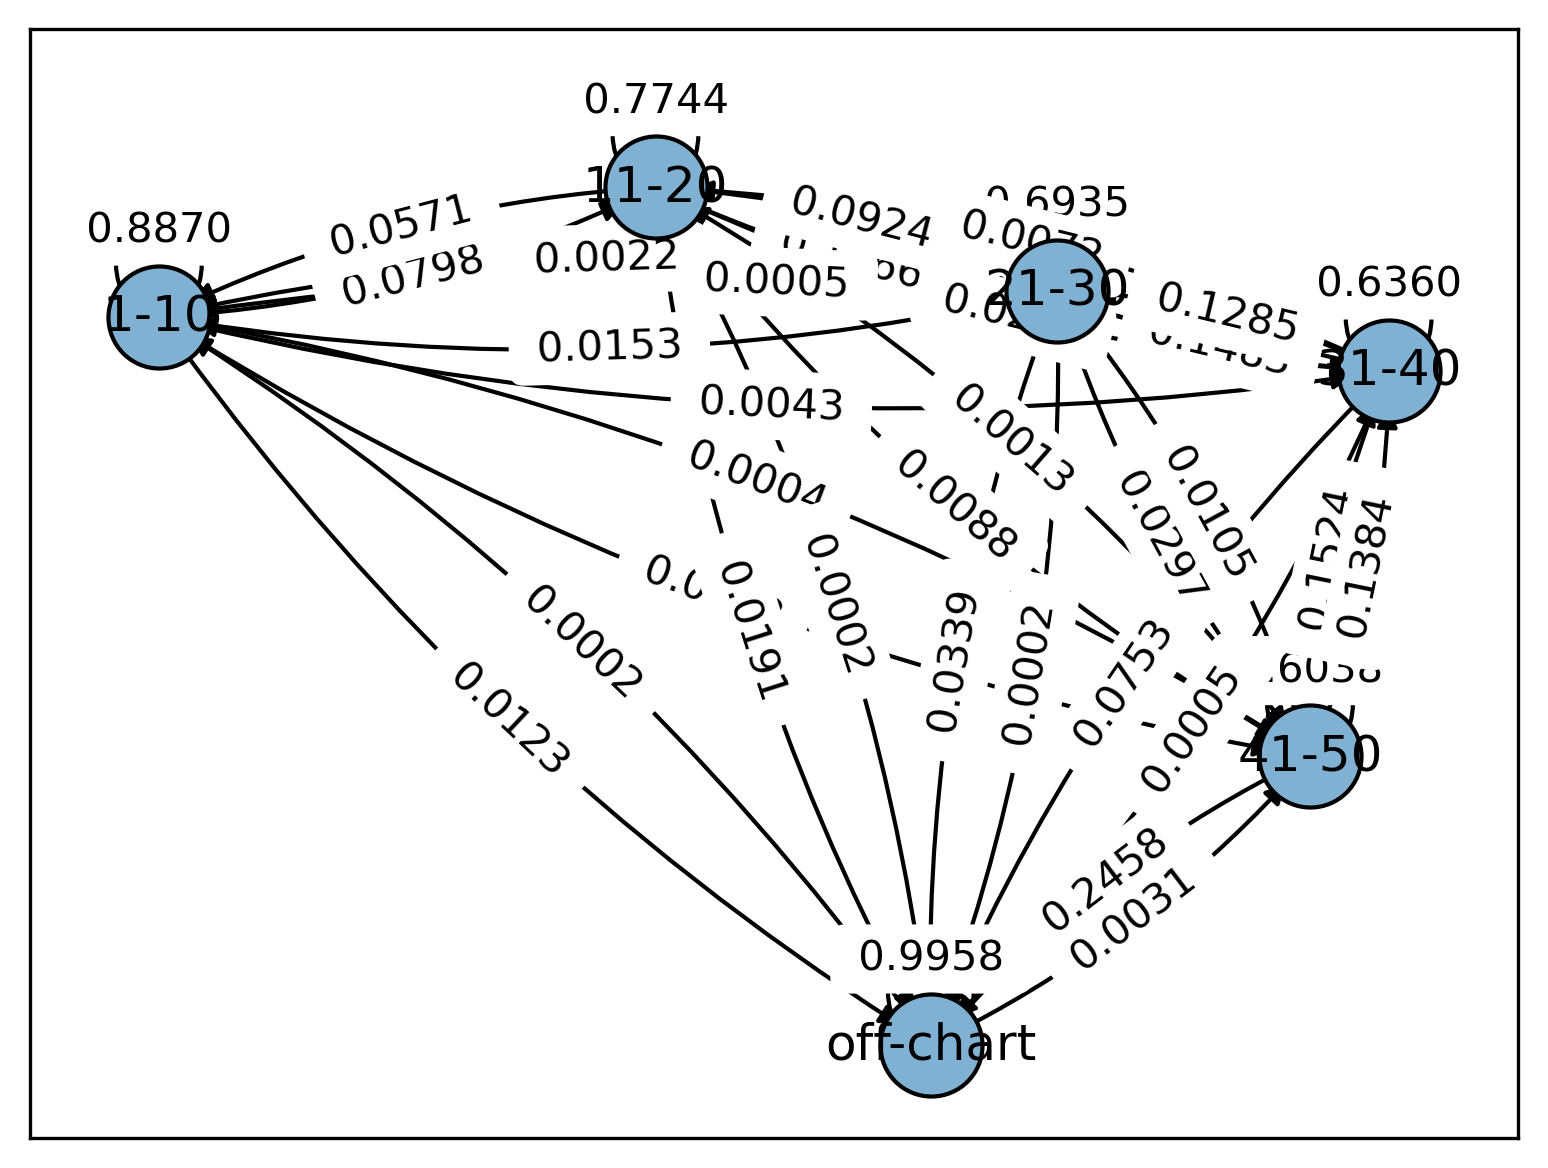

In [27]:
from pydtmc import MarkovChain, plot_graph

state_order = ["1-10", "11-20", "21-30", "31-40", "41-50", "off-chart"]

P = transition_matrix.reindex(index=state_order, columns=state_order).to_numpy()
mc = MarkovChain(P, state_order)

print(mc)
plot_graph(mc, dpi=300)

In [16]:
'''
NOTES- 

There should be  a state for not entered the chart yet , whether released on unreleased. Gives a better idea 
Creating a Markov Chain directed graph that has a more intuitive visualization. 
Looking at weekly rather than daily 
Observing edge cases where the ones that are at the beginning of the time series are immediately projected to their ranking which can skew the data 

'''



'\nNOTES- \n\nThere should be  a state for not entered the chart yet , whether released on unreleased. Gives a better idea \nCreating a Markov Chain directed graph that has a more intuitive visualization. \nLooking at weekly rather than daily \nObserving edge cases where the ones that are at the beginning of the time series are immediately projected to their ranking which can skew the data \n\n'